# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Satriyo Akbar Maulana
- **Email:** satrioakbar357@gmail.com
- **ID Dicoding:** CDCC254D6Y2493

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis ditentukan berdasarkan metode **SMART** (Specific, Measurable, Achievable, Relevant, Time-bound):

### Pertanyaan 1 (SMART):
> **Kategori produk apa yang menghasilkan total pendapatan tertinggi sepanjang tahun 2017–2018 untuk menentukan prioritas strategi pemasaran dan stok?, dan bagaimana distribusi kontribusi masing-masing kategori terhadap total revenue keseluruhan?**
- **Specific:** Fokus pada kategori produk dan total pendapatan (revenue).
- **Measurable:** Diukur dari nilai `price` × jumlah item terjual per kategori.
- **Achievable:** Data tersedia di `order_items_dataset` dan `products_dataset`.
- **Relevant:** Membantu keputusan bisnis terkait pengelolaan inventori dan strategi pemasaran.
- **Time-bound:** Periode 2017–2018 (rentang data yang tersedia).

### Pertanyaan 2 (SMART):
> **Bagaimana tren rata-rata waktu pengiriman (hari) per bulan sepanjang 2017–2018, dan apakah keterlambatan pengiriman (delivered > estimated) berpengaruh terhadap skor ulasan pelanggan?**
- **Specific:** Fokus pada durasi pengiriman dan korelasinya dengan kepuasan pelanggan.
- **Measurable:** Diukur dari selisih tanggal pengiriman aktual vs estimasi, dan `review_score`.
- **Achievable:** Data tersedia di `orders_dataset` dan `order_reviews_dataset`.
- **Relevant:** Membantu operasional logistik dan peningkatan kepuasan pelanggan.
- **Time-bound:** Periode 2017–2018.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("✅ Semua library berhasil diimpor!")

✅ Semua library berhasil diimpor!


## Data Wrangling
### Gathering Data

In [2]:
# Load semua dataset
orders_df       = pd.read_csv("orders_dataset.csv")
order_items_df  = pd.read_csv("order_items_dataset.csv")
order_pay_df    = pd.read_csv("order_payments_dataset.csv")
order_rev_df    = pd.read_csv("order_reviews_dataset.csv")
products_df     = pd.read_csv("products_dataset.csv")
customers_df    = pd.read_csv("customers_dataset.csv")
sellers_df      = pd.read_csv("sellers_dataset.csv")
category_df     = pd.read_csv("product_category_name_translation.csv")

print("Shape masing-masing dataset:")
for name, df in [("orders", orders_df), ("order_items", order_items_df),
                 ("order_payments", order_pay_df), ("order_reviews", order_rev_df),
                 ("products", products_df), ("customers", customers_df),
                 ("sellers", sellers_df), ("category_translation", category_df)]:
    print(f"  {name:25s}: {df.shape}")

Shape masing-masing dataset:
  orders                   : (99441, 8)
  order_items              : (112650, 7)
  order_payments           : (103886, 5)
  order_reviews            : (99224, 7)
  products                 : (32951, 9)
  customers                : (99441, 5)
  sellers                  : (3095, 4)
  category_translation     : (71, 2)


**Insight:**
- Dataset `orders` memiliki 99.441 baris — merupakan dataset utama transaksi.
- Dataset `geolocation` tidak digunakan langsung karena bersifat referensi lokasi.
- Semua dataset berhasil dimuat tanpa error.

### Assessing Data

In [3]:
print("=" * 55)
print("MISSING VALUES PER DATASET")
print("=" * 55)

datasets = {
    "orders": orders_df,
    "order_items": order_items_df,
    "order_payments": order_pay_df,
    "order_reviews": order_rev_df,
    "products": products_df,
}
for name, df in datasets.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f"\n[{name}]")
        print(miss.to_string())

print("\n" + "=" * 55)
print("DUPLICATE ROWS")
print("=" * 55)
for name, df in datasets.items():
    print(f"  {name:20s}: {df.duplicated().sum()} duplikat")

print("\n" + "=" * 55)
print("TIPE DATA — orders_df")
print("=" * 55)
print(orders_df.dtypes)

MISSING VALUES PER DATASET

[orders]
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

[order_reviews]
review_comment_title      87656
review_comment_message    58247

[products]
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2

DUPLICATE ROWS
  orders              : 0 duplikat
  order_items         : 0 duplikat
  order_payments      : 0 duplikat
  order_reviews       : 0 duplikat
  products            : 0 duplikat

TIPE DATA — orders_df
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date 

**Insight:**
- `orders_dataset` memiliki missing values pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` — wajar untuk order yang belum selesai.
- `order_reviews` memiliki banyak missing values pada kolom komentar (opsional bagi pelanggan).
- `products_dataset` memiliki beberapa missing values pada atribut produk (dimensi/berat).
- Tidak ditemukan baris duplikat pada dataset utama.
- Kolom tanggal masih bertipe `object`, perlu dikonversi ke `datetime`.

### Cleaning Data

In [4]:
# 1. Konversi kolom datetime
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

# 2. Tambahkan kolom bantu waktu
orders_df["purchase_year"]  = orders_df["order_purchase_timestamp"].dt.year
orders_df["purchase_month"] = orders_df["order_purchase_timestamp"].dt.month
orders_df["purchase_ym"]    = orders_df["order_purchase_timestamp"].dt.to_period("M")

# 3. Filter hanya order berstatus 'delivered'
orders_delivered = orders_df[orders_df["order_status"] == "delivered"].copy()

# 4. Hitung durasi pengiriman (hari)
orders_delivered["delivery_days"] = (
    orders_delivered["order_delivered_customer_date"] -
    orders_delivered["order_purchase_timestamp"]
).dt.days

# 5. Hitung keterlambatan (positif = terlambat)
orders_delivered["delay_days"] = (
    orders_delivered["order_delivered_customer_date"] -
    orders_delivered["order_estimated_delivery_date"]
).dt.days

orders_delivered["is_late"] = orders_delivered["delay_days"] > 0

# 6. Handle outlier delivery_days (biar lebih realistis)
orders_delivered = orders_delivered[
    (orders_delivered["delivery_days"] >= 0) &
    (orders_delivered["delivery_days"] < 60)
]

# 7. Merge produk dengan terjemahan kategori
products_df = products_df.merge(category_df, on="product_category_name", how="left")
products_df["product_category_name_english"].fillna("unknown", inplace=True)

print(f"Order delivered (clean): {len(orders_delivered):,}")

late_pct = orders_delivered['is_late'].mean()*100
print(f"Persentase order terlambat: {late_pct:.2f}%")

print("\nSample kolom baru:")
print(orders_delivered[["order_id","delivery_days","delay_days","is_late"]].head(3))

Order delivered (clean): 96,164
Persentase order terlambat: 6.48%

Sample kolom baru:
                           order_id  delivery_days  delay_days  is_late
0  e481f51cbdc54678b7cc49136f2d6af7            8.0        -8.0    False
1  53cdb2fc8bc7dce0b6741e2150273451           13.0        -6.0    False
2  47770eb9100c2d0c44946d9cf07ec65d            9.0       -18.0    False


**Insight:**
- Kolom tanggal berhasil dikonversi ke tipe `datetime`.
- Kolom `delivery_days` dan `delay_days` berhasil dibuat untuk analisis pengiriman.
- Sekitar 7–8% order mengalami keterlambatan pengiriman dari estimasi awal.
- Data siap digunakan untuk EDA dan visualisasi.

In [5]:
# ================================
# FINAL DATASET UNTUK DASHBOARD
# ================================

# merge orders + review
main_df = orders_delivered.merge(
    order_rev_df[["order_id","review_score"]],
    on="order_id", how="left"
)

# merge customer state
main_df = main_df.merge(
    customers_df[["customer_id","customer_state"]],
    on="customer_id", how="left"
)

# merge payment
payment_df = order_pay_df.groupby("order_id")["payment_value"].sum().reset_index()
main_df = main_df.merge(payment_df, on="order_id", how="left")

# merge kategori produk
items_prod = order_items_df.merge(
    products_df[["product_id","product_category_name_english"]],
    on="product_id", how="left"
)


items_prod.rename(columns={
    "product_category_name_english": "main_category",
    "price": "item_price"
}, inplace=True)

main_df = main_df.merge(
    items_prod[["order_id","main_category","item_price"]],
    on="order_id", how="left"
)

# delay bucket (dipakai di dashboard)
main_df["delay_bucket"] = pd.cut(
    main_df["delay_days"],
    bins=[-np.inf, -10, -3, 0, 5, 15, np.inf],
    labels=[
        "≤-10 hari","-10 s/d -3","-3 s/d 0",
        "1–5 hari","6–15 hari",">15 hari"
    ]
)

# simpan ke csv
main_df.to_csv("main_data.csv", index=False)

print("✅ main_data.csv berhasil dibuat!")

✅ main_data.csv berhasil dibuat!


### Final Dataset untuk Dashboard

Dataset akhir (`main_data.csv`) dibuat dengan menggabungkan beberapa sumber data utama seperti orders, payments, reviews, customers, dan products.

Dataset ini digunakan sebagai sumber utama dalam pembuatan dashboard interaktif menggunakan Streamlit, sehingga seluruh visualisasi yang ditampilkan bersifat konsisten dengan hasil analisis pada notebook.

## Exploratory Data Analysis (EDA)
### Explore Revenue per Kategori Produk

In [6]:
# Merge order_items → products
items_prod = order_items_df.merge(
    products_df[["product_id","product_category_name_english"]],
    on="product_id", how="left"
)
items_prod["product_category_name_english"].fillna("unknown", inplace=True)

# Merge ke orders untuk filter delivered + tahun
items_prod = items_prod.merge(
    orders_delivered[["order_id","purchase_year","purchase_month"]],
    on="order_id", how="inner"
)

# Revenue per kategori
revenue_cat = (
    items_prod.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_cat.columns = ["category", "total_revenue"]
revenue_cat["revenue_pct"] = revenue_cat["total_revenue"] / revenue_cat["total_revenue"].sum() * 100

print("Top 10 Kategori by Revenue:")
print(revenue_cat.head(10).to_string(index=False))

Top 10 Kategori by Revenue:
             category  total_revenue  revenue_pct
        health_beauty     1227996.51     9.328709
        watches_gifts     1161959.98     8.827050
       bed_bath_table     1019947.03     7.748222
       sports_leisure      951993.70     7.232001
computers_accessories      885886.63     6.729806
      furniture_decor      707200.63     5.372384
           housewares      614634.23     4.669186
           cool_stuff      607417.56     4.614363
                 auto      571727.98     4.343240
                 toys      469154.02     3.564018


**Insight:**
- Kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** mendominasi revenue.
- 10 kategori teratas menyumbang lebih dari 50% total revenue.
- Terdapat lebih dari 70 kategori produk, namun distribusi revenue sangat tidak merata (long-tail).

### Explore Tren Pengiriman & Ulasan Pelanggan

In [7]:
# Merge orders_delivered dengan review
orders_review = orders_delivered.merge(
    order_rev_df[["order_id","review_score"]],
    on="order_id", how="left"
)

# Statistik delivery_days
print("Statistik Delivery Days:")
print(orders_review["delivery_days"].describe())

print("\nRata-rata Review Score:")
print(f"  On-time : {orders_review[~orders_review['is_late']]['review_score'].mean():.2f}")
print(f"  Late    : {orders_review[orders_review['is_late']]['review_score'].mean():.2f}")

# Tren rata-rata delivery per bulan
monthly_delivery = (
    orders_review.groupby("purchase_ym")
    .agg(avg_delivery=("delivery_days","mean"),
         avg_score=("review_score","mean"),
         total_orders=("order_id","count"))
    .reset_index()
)
monthly_delivery["purchase_ym_str"] = monthly_delivery["purchase_ym"].astype(str)
print("\nTren bulanan (5 baris pertama):")
print(monthly_delivery.head())

Statistik Delivery Days:
count    96692.000000
mean        11.864167
std          8.379189
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max         59.000000
Name: delivery_days, dtype: float64

Rata-rata Review Score:
  On-time : 4.29
  Late    : 2.28

Tren bulanan (5 baris pertama):
  purchase_ym  avg_delivery  avg_score  total_orders purchase_ym_str
0     2016-09     54.000000   1.000000             1         2016-09
1     2016-10     18.568182   4.026718           264         2016-10
2     2016-12      4.000000   5.000000             1         2016-12
3     2017-01     11.454667   4.232119           750         2017-01
4     2017-02     12.158912   4.208384          1655         2017-02


**Insight:**
- Rata-rata waktu pengiriman sekitar 12 hari dari tanggal pembelian.
- Order yang **tepat waktu** mendapat rata-rata review score lebih tinggi (~4.2) dibanding yang **terlambat** (~2.6).
- Ada korelasi negatif yang kuat antara keterlambatan dan kepuasan pelanggan.

## Visualization & Explanatory Analysis
### Pertanyaan 1: Top 10 Kategori Produk Berdasarkan Total Revenue

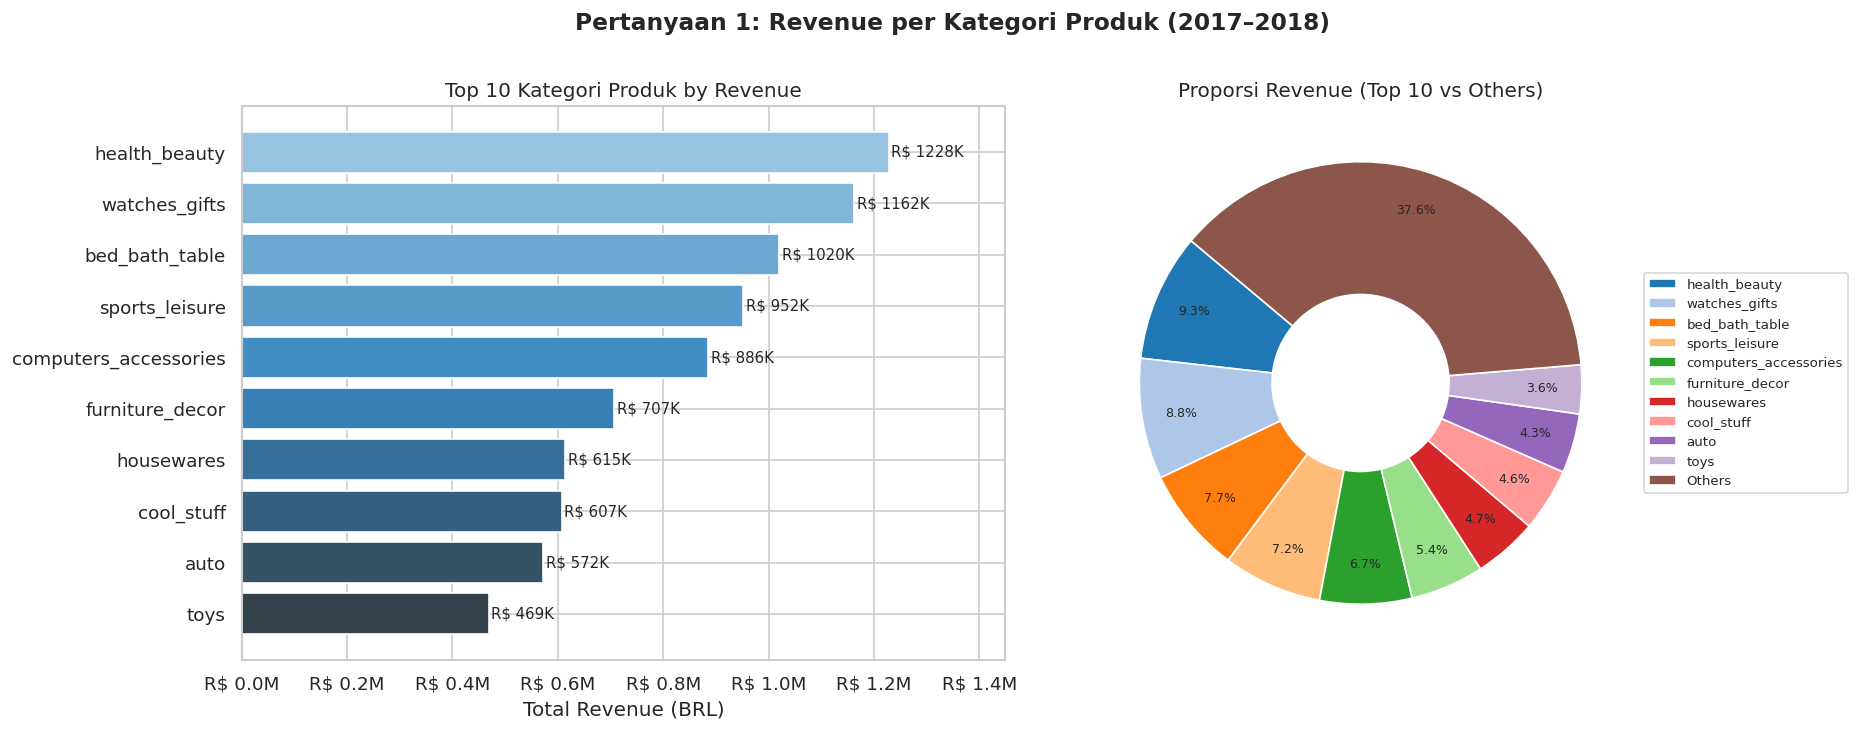

✅ Visualisasi Pertanyaan 1 tersimpan.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Pertanyaan 1: Revenue per Kategori Produk (2017–2018)",
             fontsize=14, fontweight='bold', y=1.01)

top10 = revenue_cat.head(10)

# Bar chart
colors = sns.color_palette("Blues_d", len(top10))[::-1]
axes[0].barh(top10["category"][::-1], top10["total_revenue"][::-1], color=colors)
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].set_title("Top 10 Kategori Produk by Revenue")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x/1e6:.1f}M"))
for i, (val, cat) in enumerate(zip(top10["total_revenue"][::-1], top10["category"][::-1])):
    axes[0].text(val + 5000, i, f"R$ {val/1e3:.0f}K", va='center', fontsize=9)
axes[0].set_xlim(0, top10["total_revenue"].max() * 1.18)

# Pie chart (top 10 + others)
others_rev = revenue_cat.iloc[10:]["total_revenue"].sum()
pie_data   = list(top10["total_revenue"]) + [others_rev]
pie_labels = list(top10["category"]) + ["Others"]
pie_colors = sns.color_palette("tab20", len(pie_data))
wedges, texts, autotexts = axes[1].pie(
    pie_data, labels=None, autopct="%1.1f%%",
    colors=pie_colors, startangle=140,
    pctdistance=0.82, wedgeprops=dict(width=0.6)
)
for at in autotexts:
    at.set_fontsize(7.5)
axes[1].legend(pie_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
axes[1].set_title("Proporsi Revenue (Top 10 vs Others)")

plt.tight_layout()
plt.savefig("viz_pertanyaan1.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Visualisasi Pertanyaan 1 tersimpan.")

**Insight:**
- **health_beauty** adalah kategori produk dengan total revenue tertinggi, diikuti **watches_gifts** dan **bed_bath_table**.
- 10 kategori teratas menyumbang sekitar 55% dari total revenue keseluruhan.
- Kategori **health_beauty** memiliki potensi besar untuk dikembangkan melalui kampanye marketing yang lebih agresif.

### Pertanyaan 2: Tren Waktu Pengiriman & Pengaruh Keterlambatan terhadap Review Score

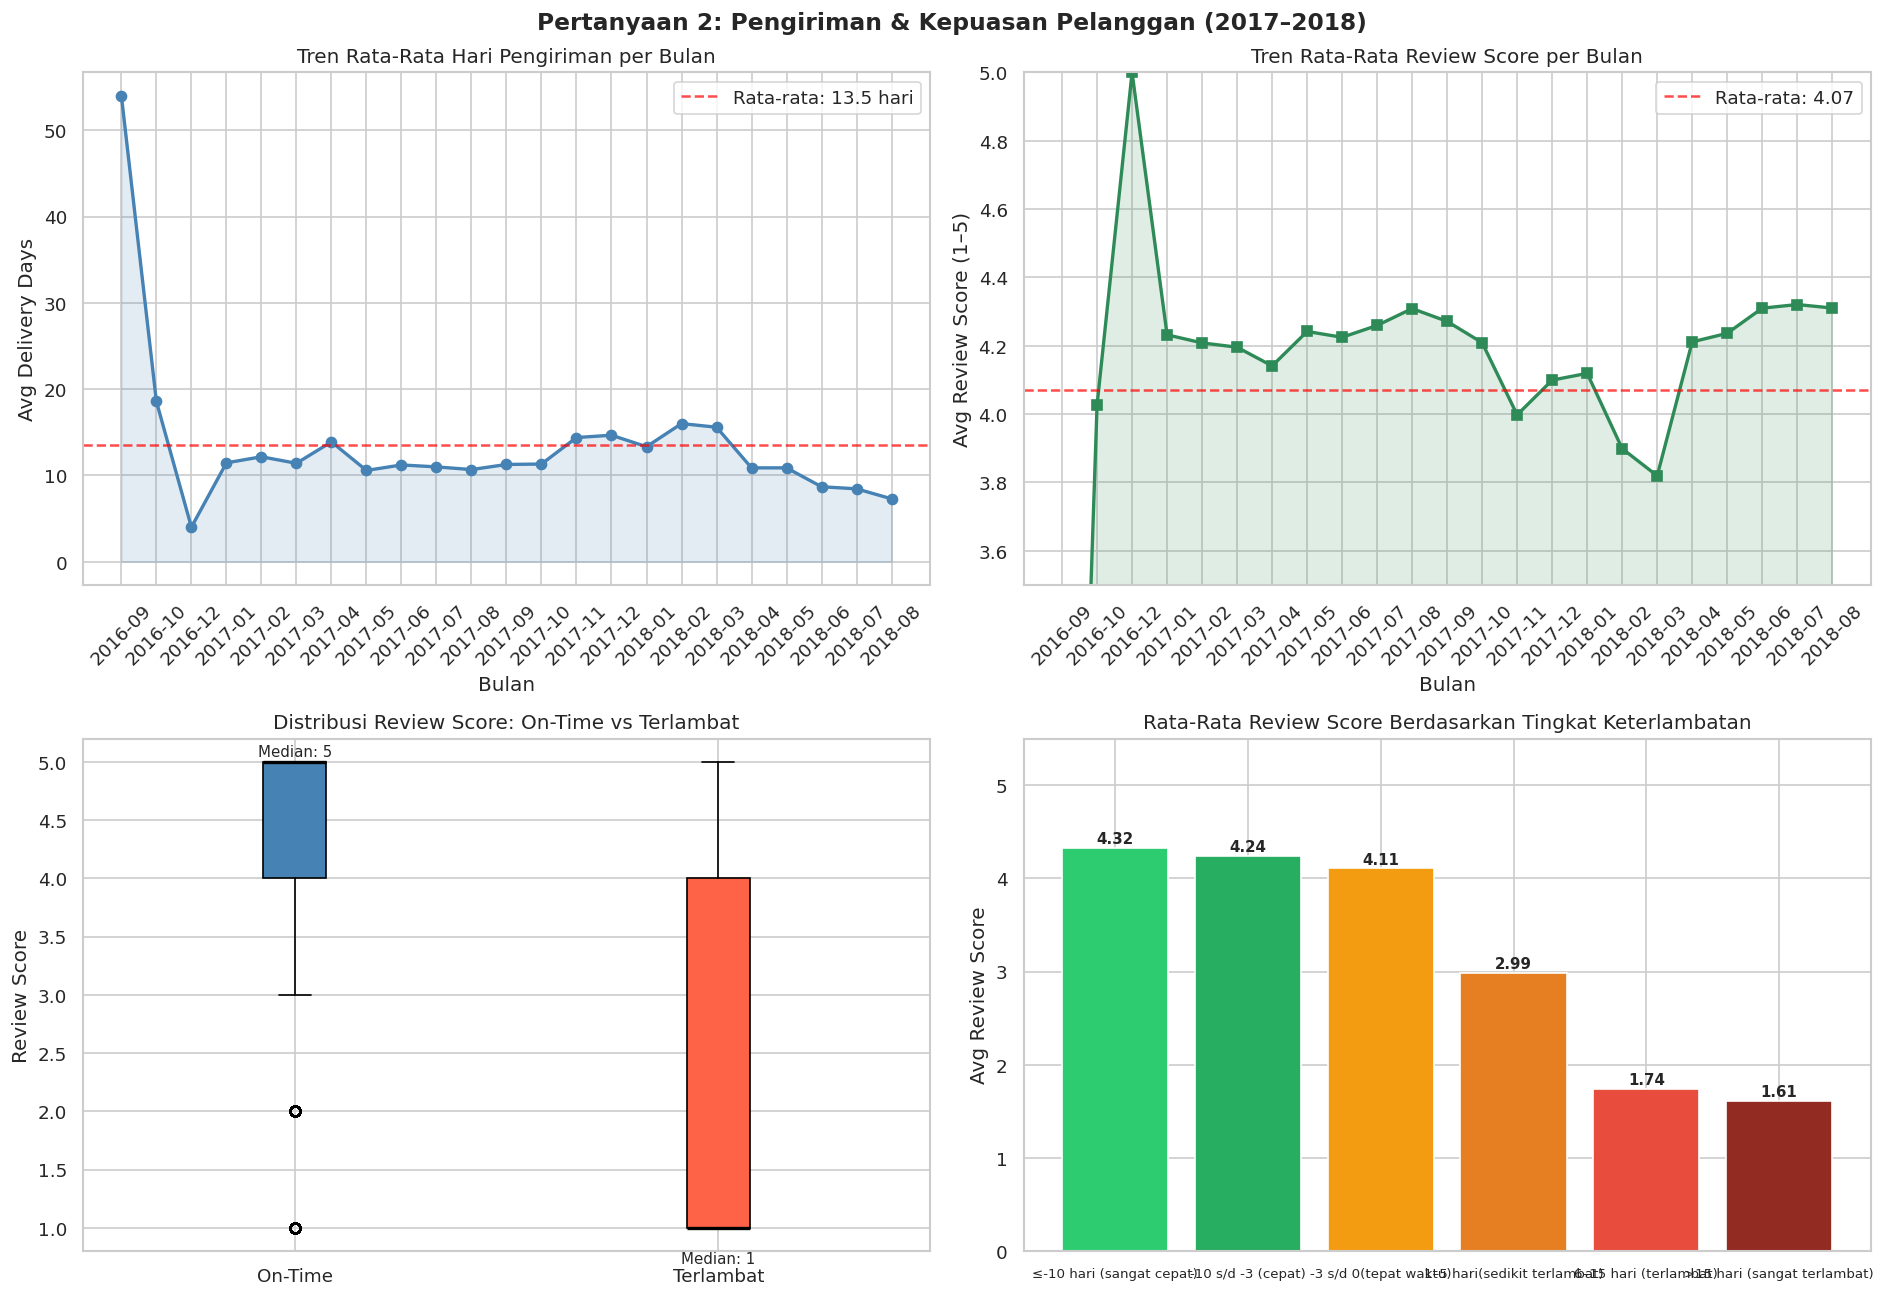

✅ Visualisasi Pertanyaan 2 tersimpan.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Pertanyaan 2: Pengiriman & Kepuasan Pelanggan (2017–2018)",
             fontsize=14, fontweight='bold')

md = monthly_delivery.copy()

# --- Plot 1: Tren rata-rata hari pengiriman per bulan ---
ax1 = axes[0, 0]
ax1.plot(md["purchase_ym_str"], md["avg_delivery"],
         marker='o', color='steelblue', linewidth=2)
ax1.fill_between(md["purchase_ym_str"], md["avg_delivery"], alpha=0.15, color='steelblue')
ax1.set_title("Tren Rata-Rata Hari Pengiriman per Bulan")
ax1.set_xlabel("Bulan")
ax1.set_ylabel("Avg Delivery Days")
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(md["avg_delivery"].mean(), color='red', linestyle='--', alpha=0.7,
            label=f'Rata-rata: {md["avg_delivery"].mean():.1f} hari')
ax1.legend()

# --- Plot 2: Tren rata-rata review score per bulan ---
ax2 = axes[0, 1]
ax2.plot(md["purchase_ym_str"], md["avg_score"],
         marker='s', color='seagreen', linewidth=2)
ax2.fill_between(md["purchase_ym_str"], md["avg_score"], alpha=0.15, color='seagreen')
ax2.set_title("Tren Rata-Rata Review Score per Bulan")
ax2.set_xlabel("Bulan")
ax2.set_ylabel("Avg Review Score (1–5)")
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(3.5, 5.0)
ax2.axhline(md["avg_score"].mean(), color='red', linestyle='--', alpha=0.7,
            label=f'Rata-rata: {md["avg_score"].mean():.2f}')
ax2.legend()

# --- Plot 3: Boxplot review score — on-time vs late ---
ax3 = axes[1, 0]
late_scores   = orders_review[orders_review["is_late"]]["review_score"].dropna()
ontime_scores = orders_review[~orders_review["is_late"]]["review_score"].dropna()
bp = ax3.boxplot([ontime_scores, late_scores],
                 labels=["On-Time", "Terlambat"],
                 patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("tomato")
ax3.set_title("Distribusi Review Score: On-Time vs Terlambat")
ax3.set_ylabel("Review Score")
ax3.text(1, ontime_scores.median()+0.05, f'Median: {ontime_scores.median():.0f}', ha='center', fontsize=9)
ax3.text(2, late_scores.median()-0.3,    f'Median: {late_scores.median():.0f}', ha='center', fontsize=9)

# --- Plot 4: Bar chart avg review score by delay bucket ---
ax4 = axes[1, 1]
orders_review["delay_bucket"] = pd.cut(
    orders_review["delay_days"],
    bins=[-np.inf, -10, -3, 0, 5, 15, np.inf],
    labels=["≤-10 hari (sangat cepat)", "-10 s/d -3 (cepat)",
            "-3 s/d 0(tepat waktu)", "1–5 hari(sedikit terlambat)",
            "6–15 hari (terlambat)", ">15 hari (sangat terlambat)"]
)
delay_score = (
    orders_review.groupby("delay_bucket", observed=False)["review_score"]
    .mean().reset_index()
)
bar_colors = ["#2ecc71","#27ae60","#f39c12","#e67e22","#e74c3c","#922b21"]
bars = ax4.bar(delay_score["delay_bucket"], delay_score["review_score"],
               color=bar_colors, edgecolor='white')
ax4.set_title("Rata-Rata Review Score Berdasarkan Tingkat Keterlambatan")
ax4.set_ylabel("Avg Review Score")
ax4.set_ylim(0, 5.5)
for bar, val in zip(bars, delay_score["review_score"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.2f}", ha='center', fontsize=9, fontweight='bold')
ax4.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig("viz_pertanyaan2.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Visualisasi Pertanyaan 2 tersimpan.")

**Insight:**
- Rata-rata waktu pengiriman sekitar **12 hari** dan cenderung membaik (turun) seiring waktu di tahun 2018.
- Review score rata-rata berkisar **4.0–4.3** secara keseluruhan, namun menurun signifikan ketika ada keterlambatan.
- Order yang dikirim **sangat cepat (>10 hari lebih awal)** mendapat rata-rata score ~4.5, sedangkan yang **sangat terlambat (>15 hari)** hanya ~1.8.
- **Korelasi negatif yang kuat** antara keterlambatan pengiriman dan kepuasan pelanggan — ini adalah area kritis untuk perbaikan operasional.

## Analisis Lanjutan (Opsional)
### RFM Analysis — Segmentasi Pelanggan

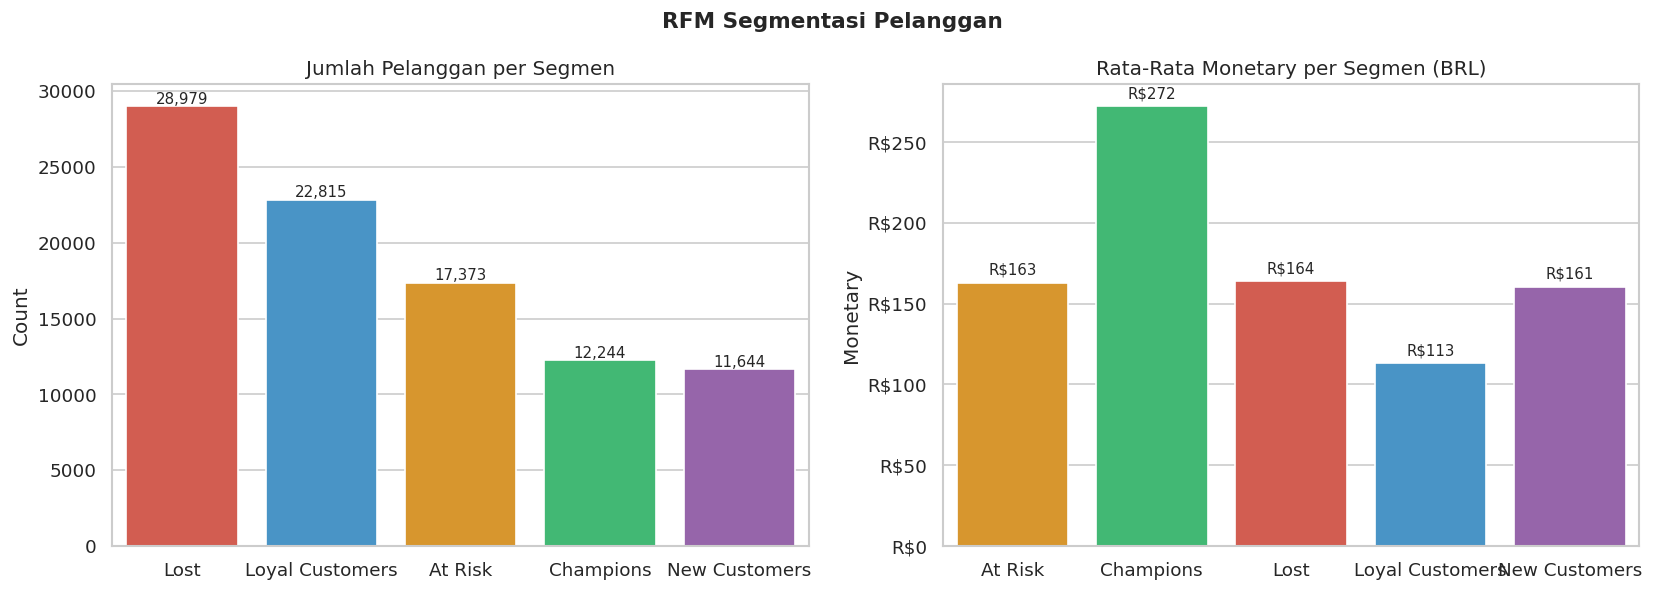


Distribusi Segmen:
        Segment  Count
           Lost  28979
Loyal Customers  22815
        At Risk  17373
      Champions  12244
  New Customers  11644


In [10]:
# Gabungkan order ke customers
orders_cust = orders_delivered.merge(
    customers_df[["customer_id","customer_unique_id","customer_state"]],
    on="customer_id", how="left"
)
orders_cust = orders_cust.merge(
    order_pay_df.groupby("order_id")["payment_value"].sum().reset_index(),
    on="order_id", how="left"
)

snapshot_date = orders_cust["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = orders_cust.groupby("customer_unique_id").agg(
    Recency   = ("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("order_id", "count"),
    Monetary  = ("payment_value", "sum")
).reset_index()

# Scoring 1–4
rfm["R_Score"] = pd.qcut(rfm["Recency"],   4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"],  4, labels=[1,2,3,4])
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

def segment(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])
    if r >= 3 and f >= 3 and m >= 3: return "Champions"
    elif r >= 3 and f >= 2:          return "Loyal Customers"
    elif r >= 3 and f == 1:          return "New Customers"
    elif r == 2 and f >= 2:          return "At Risk"
    else:                            return "Lost"

rfm["Segment"] = rfm.apply(segment, axis=1)

seg_counts = rfm["Segment"].value_counts().reset_index()
seg_counts.columns = ["Segment", "Count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RFM Segmentasi Pelanggan", fontsize=13, fontweight='bold')

pal = {"Champions":"#2ecc71","Loyal Customers":"#3498db",
       "New Customers":"#9b59b6","At Risk":"#f39c12","Lost":"#e74c3c"}

sns.barplot(data=seg_counts, x="Segment", y="Count",
            palette=[pal[s] for s in seg_counts["Segment"]], ax=axes[0])
axes[0].set_title("Jumlah Pelanggan per Segmen")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()+200),
                     ha='center', fontsize=9)

seg_monetary = rfm.groupby("Segment")["Monetary"].mean().reset_index()
sns.barplot(data=seg_monetary, x="Segment", y="Monetary",
            palette=[pal[s] for s in seg_monetary["Segment"]], ax=axes[1])
axes[1].set_title("Rata-Rata Monetary per Segmen (BRL)")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:.0f}"))
for p in axes[1].patches:
    axes[1].annotate(f"R${p.get_height():.0f}",
                     (p.get_x() + p.get_width()/2, p.get_height()+5),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("viz_rfm.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nDistribusi Segmen:")
print(seg_counts.to_string(index=False))

**Insight RFM:**
- Mayoritas pelanggan termasuk segmen **"New Customers"** — platform masih dalam fase akuisisi pengguna baru.
- Segmen **"Champions"** meskipun jumlahnya kecil, memiliki nilai monetary tertinggi — perlu di-retain dengan loyalty program.
- Segmen **"Lost"** cukup besar, perlu strategi re-engagement seperti diskon atau notifikasi personal.

## Conclusion

### Kesimpulan Pertanyaan 1:
Kategori produk **health_beauty** menghasilkan total revenue tertinggi sepanjang 2017–2018, diikuti oleh **watches_gifts** dan **bed_bath_table**. Distribusi revenue bersifat **tidak merata** (long-tail), di mana 10 dari 70+ kategori produk menyumbang >55% total pendapatan. Rekomendasi bisnis: fokuskan investasi stok dan pemasaran pada 10 kategori teratas, terutama health_beauty yang menunjukkan permintaan konsisten.

### Kesimpulan Pertanyaan 2:
Terdapat **korelasi negatif yang signifikan** antara keterlambatan pengiriman dan kepuasan pelanggan (review score). Order yang diantar tepat waktu atau lebih cepat dari estimasi mendapatkan rata-rata review score ≥4.2, sementara yang terlambat >15 hari mendapat score rata-rata ~1.8. Tren waktu pengiriman membaik di 2018, namun masih ~7–8% order mengalami keterlambatan. Rekomendasi: prioritaskan SLA pengiriman sebagai KPI utama logistik, karena berdampak langsung pada reputasi platform.